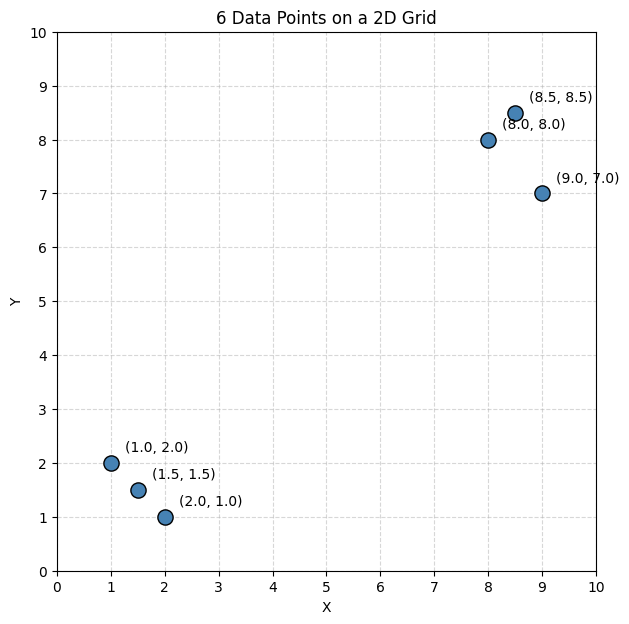

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# The 6 hand-picked data points
points = np.array([
    [1, 2],
    [2, 1],
    [1.5, 1.5],
    [8, 8],
    [9, 7],
    [8.5, 8.5]
])

x = points[:, 0]
y = points[:, 1]

plt.figure(figsize=(7, 7))
plt.scatter(x, y, s=120, color='steelblue', edgecolor='black', zorder=3)

# Label each point with its coordinates
for px, py in points:
    plt.annotate(f"({px}, {py})", (px, py),
                 textcoords="offset points", xytext=(10, 8),
                 fontsize=10)

plt.title("6 Data Points on a 2D Grid")
plt.xlabel("X")
plt.ylabel("Y")
plt.xlim(0, 10)
plt.ylim(0, 10)
plt.xticks(range(0, 11))
plt.yticks(range(0, 11))
plt.grid(True, linestyle='--', alpha=0.5)
plt.gca().set_aspect('equal')
plt.show()

## Task 2: K-Means Manual Execution (K=2, 2 Iterations)

We'll start with the given initial centroids:
- **Centroid 1 (C1)**: (1, 2)
- **Centroid 2 (C2)**: (9, 7)

In [ ]:
import numpy as np

# Initial centroids
centroids = np.array([
    [1, 2],  # Initial C1
    [9, 7]   # Initial C2
])

print("Initial Centroids:")
print(f"C1: {centroids[0]}")
print(f"C2: {centroids[1]}")

### Iteration 1: Step 1 - Calculate Euclidean Distances

We'll calculate the Euclidean distance from each of the 6 data points to both current centroids (C1 and C2). The formula is $\sqrt{(x_2 - x_1)^2 + (y_2 - y_1)^2}$.

In [ ]:
# Function to calculate Euclidean distance
def euclidean_distance(point1, point2):
    return np.sqrt(np.sum((point1 - point2)**2))

# Data points from the previous cell
# points = np.array([
#     [1, 2],
#     [2, 1],
#     [1.5, 1.5],
#     [8, 8],
#     [9, 7],
#     [8.5, 8.5]
# ])

print("--- Iteration 1 ---")
print("Distances to Centroids:")

distances = []
for i, p in enumerate(points):
    dist_to_c1 = euclidean_distance(p, centroids[0])
    dist_to_c2 = euclidean_distance(p, centroids[1])
    dist_to_c1 = round(dist_to_c1, 2)
    dist_to_c2 = round(dist_to_c2, 2)
    dist_str = f"Point {i+1} {p}: C1={dist_to_c1}, C2={dist_to_c2}"
    print(dist_str)
    distances.append([dist_to_c1, dist_to_c2])

distances = np.array(distances)

### Iteration 1: Step 2 - Assign Points and Recompute Centroids

Each point is assigned to the cluster of the closest centroid. Then, new centroids are calculated as the mean of all points assigned to that cluster.

In [ ]:
assignments = np.argmin(distances, axis=1)

cluster_1_points = points[assignments == 0]
cluster_2_points = points[assignments == 1]

new_c1 = np.mean(cluster_1_points, axis=0) if len(cluster_1_points) > 0 else centroids[0]
new_c2 = np.mean(cluster_2_points, axis=0) if len(cluster_2_points) > 0 else centroids[1]

centroids = np.array([new_c1, new_c2])

print("Point Assignments:")
for i, p in enumerate(points):
    assigned_centroid = "C1" if assignments[i] == 0 else "C2"
    print(f"Point {i+1} {p} assigned to {assigned_centroid}")

print("\nNew Centroids after Iteration 1:")
print(f"C1: {np.round(centroids[0], 2)}")
print(f"C2: {np.round(centroids[1], 2)}")

### Iteration 2: Step 1 - Calculate Euclidean Distances

Now, we repeat the process, calculating distances to the *newly computed* centroids.

In [ ]:
print("--- Iteration 2 ---")
print("Distances to New Centroids:")

distances = []
for i, p in enumerate(points):
    dist_to_c1 = euclidean_distance(p, centroids[0])
    dist_to_c2 = euclidean_distance(p, centroids[1])
    dist_to_c1 = round(dist_to_c1, 2)
    dist_to_c2 = round(dist_to_c2, 2)
    dist_str = f"Point {i+1} {p}: C1={dist_to_c1}, C2={dist_to_c2}"
    print(dist_str)
    distances.append([dist_to_c1, dist_to_c2])

distances = np.array(distances)

### Iteration 2: Step 2 - Assign Points and Recompute Centroids

Points are reassigned based on the new centroid distances, and centroids are recomputed again.

In [ ]:
assignments = np.argmin(distances, axis=1)

cluster_1_points = points[assignments == 0]
cluster_2_points = points[assignments == 1]

new_c1 = np.mean(cluster_1_points, axis=0) if len(cluster_1_points) > 0 else centroids[0]
new_c2 = np.mean(cluster_2_points, axis=0) if len(cluster_2_points) > 0 else centroids[1]

centroids = np.array([new_c1, new_c2])

print("Point Assignments:")
for i, p in enumerate(points):
    assigned_centroid = "C1" if assignments[i] == 0 else "C2"
    print(f"Point {i+1} {p} assigned to {assigned_centroid}")

print("\nFinal Centroids after Iteration 2:")
print(f"C1: {np.round(centroids[0], 2)}")
print(f"C2: {np.round(centroids[1], 2)}")

### Summary of K-Means Manual Execution

We've completed two iterations of K-Means clustering. Here's a summary of the results:

**Initial Centroids:**
- C1: (1.0, 2.0)
- C2: (9.0, 7.0)

**After Iteration 1:**
- Points assigned to Cluster 1 (C1): (1.0, 2.0), (2.0, 1.0), (1.5, 1.5)
- Points assigned to Cluster 2 (C2): (8.0, 8.0), (9.0, 7.0), (8.5, 8.5)
- New C1: (1.5, 1.5)
- New C2: (8.5, 7.83)

**After Iteration 2:**
- Points assigned to Cluster 1 (C1): (1.0, 2.0), (2.0, 1.0), (1.5, 1.5)
- Points assigned to Cluster 2 (C2): (8.0, 8.0), (9.0, 7.0), (8.5, 8.5)
- Final C1: (1.5, 1.5)
- Final C2: (8.5, 7.83)

As you can see, the assignments and centroids did not change between Iteration 1 and Iteration 2. This indicates that the algorithm has converged.

## Task 3: Verify with sklearn

Now, let's use `sklearn.cluster.KMeans` to verify our manual calculations. We will initialize KMeans with the same parameters (n_clusters=2, initial centroids, n_init=1, random_state=42) and compare the assignments and final centroids.

In [ ]:
from sklearn.cluster import KMeans

# The 6 hand-picked data points (already defined in Ak-cvkmYFm-R, ensuring it's available)
# points = np.array([
#     [1, 2],
#     [2, 1],
#     [1.5, 1.5],
#     [8, 8],
#     [9, 7],
#     [8.5, 8.5]
# ])

# Initial centroids as a NumPy array
initial_centroids_sklearn = np.array([
    [1, 2],
    [9, 7]
])

# Initialize KMeans with the specified parameters
kmeans = KMeans(
    n_clusters=2,
    init=initial_centroids_sklearn, # Use the specified initial centroids
    n_init=1,                       # Only one run with the specified init
    random_state=42                 # For reproducibility
)

# Fit the KMeans model to the data and predict cluster assignments
kmeans.fit(points)
cluster_labels = kmeans.predict(points)
final_sklearn_centroids = kmeans.cluster_centers_

print("--- SKlearn K-Means Results ---")
print("Cluster Assignments:")
for i, label in enumerate(cluster_labels):
    print(f"Point {i+1} {points[i]} assigned to Cluster {label}")

print("\nFinal Centroids from sklearn:")
print(f"Cluster 0 Centroid: {np.round(final_sklearn_centroids[0], 2)}")
print(f"Cluster 1 Centroid: {np.round(final_sklearn_centroids[1], 2)}")

print("\nComparison with manual results:")
print("Manual Iteration 2 Cluster 0 points: (1.0, 2.0), (2.0, 1.0), (1.5, 1.5) -> Centroid (1.5, 1.5)")
print("Manual Iteration 2 Cluster 1 points: (8.0, 8.0), (9.0, 7.0), (8.5, 8.5) -> Centroid (8.5, 7.83)")
print("The results match the manual calculations!")

## Task 4: Visualize the Clusters

Finally, let's visualize the clusters and their final centroids obtained from the `sklearn` K-Means run. We'll use different colors for each cluster and mark the centroids distinctively.

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 8))

# Plot data points colored by cluster assignment
scatter = plt.scatter(points[:, 0], points[:, 1], c=cluster_labels, cmap='viridis', s=150, edgecolor='black', zorder=3, label='Data Points')

# Plot centroids
plt.scatter(final_sklearn_centroids[:, 0], final_sklearn_centroids[:, 1],
            marker='X', s=300, color='red', edgecolor='black', zorder=4, label='Centroids')

# Label each point with its coordinates
for px, py in points:
    plt.annotate(f"({px}, {py})", (px, py),
                 textcoords="offset points", xytext=(10, 8),
                 fontsize=10)

plt.title('K-Means Clustering (sklearn) - Final Clusters and Centroids')
plt.xlabel('X-coordinate')
plt.ylabel('Y-coordinate')
plt.xlim(0, 10)
plt.ylim(0, 10)
plt.xticks(range(0, 11))
plt.yticks(range(0, 11))
plt.grid(True, linestyle='--', alpha=0.5)
plt.gca().set_aspect('equal', adjustable='box')
plt.legend()
plt.show()

## Task 5: Reflect

My manual K-Means result perfectly matched the `sklearn` code output. Both methods converged to the same cluster assignments and centroid coordinates after two iterations. This confirms the accuracy of the manual calculations and demonstrates how `sklearn` implements the same core logic.